In [ ]:
#importing required libraries
import os 
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import  datetime as dt
import math

from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler


%matplotlib inline
pd.options.display.float_format='{:,.2f}'.format
np.set_printoptions(precision=2)
warnings.filterwarnings('ignore') #specify to ignore  warning messages

In [ ]:
import pandas as pd
#reading current data
df=pd.read_csv('energy.csv',parse_dates=['timestamp'],index_col=['timestamp'])
energy=df['load'].to_frame()
energy.head()
# !pip3 list|grep -i "statsmodels"

In [ ]:
energy.plot(
    y='load',
    subplots=True,
    figsize=(15,8),
    fontsize=12
)
plt.xlabel('timestamp',fontsize=12)
plt.ylabel('load',fontsize=12)
plt.show()

In [ ]:
train_start_dt = '2014-11-01 00:00:00'
test_start_dt = '2014-12-30 00:00:00'

# print(energy.head())
# print(energy)
# print(energy.index.names)

energy[(energy.index < test_start_dt) & (energy.index >= train_start_dt)][['load']].rename(columns={'load':'train'}) \
    .join(energy[test_start_dt:][['load']].rename(columns={'load':'test'}), how='outer') \
    .plot(y=['train', 'test'], figsize=(15, 8), fontsize=12)
plt.xlabel('timestamp', fontsize=12)
plt.ylabel('load', fontsize=12)
plt.show()

In [ ]:
train = energy.copy()[(energy.index >= train_start_dt) & (energy.index < test_start_dt)][['load']]
test = energy.copy()[energy.index >= test_start_dt][['load']]

print('Training data shape: ', train.shape)
print('Test data shape: ', test.shape)

In [ ]:
scaler=MinMaxScaler()
# train['load']=scaler.fit_transform(train['load'].to_frame())
train['load']=scaler.fit_transform(train)
train.head()

In [ ]:
energy[(energy.index >= train_start_dt) & (energy.index < test_start_dt)][['load']].rename(columns={'load':'original load'}).plot.hist(bins=100, fontsize=12)
train.rename(columns={'load':'scaled load'}).plot.hist(bins=100, fontsize=12)
plt.show()

In [ ]:
test['load']=scaler.transform(test)
test.head()

In [ ]:
#Specify the number of steps to forecast ahead
HORIZON=3
print('forecasting horizon:',HORIZON,'hours')

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

order=(4,1,0)
seasonal_order=(1,1,0,24)

model=SARIMAX(endog=train,order=order,seasonal_order=seasonal_order)
results=model.fit()

In [ ]:
print(results.summary())

In [ ]:
#creating dataset point for each horizon step
test_shifted=test.copy()

for t in range(1,HORIZON+1):
    test_shifted['load'+str(t)]=test_shifted['load'].shift(
        -t,freq='h'
    )

test_shifted=test_shifted.dropna(how='any')
test_shifted.head(5)


In [ ]:
##Making predictions on your test data using this sliding window
#approach in a loop the size of the test data length:
# %%time 
training_window=720 # dedicate 30 days (720 hours) for training

train_ts=train['load']
test_ts=test_shifted

history=[x for x in train_ts]
history=history[(-training_window):]

predictions=list()

order=(2,1,0)
seasonal_order=(1,1,0,24)

for t in range(test_ts.shape[0]):
    model=SARIMAX(
        endog=history,
        order=order,
        seasonal_order=seasonal_order
    )
    model_fit=model.fit()
    yhat=model_fit.forecast(steps=HORIZON)
    predictions.append(yhat)
    obs=list(test_ts.iloc[t])
    #move the training window
    history.append(obs[0])
    history.pop(0)
    print(test_ts.index[t])
    print(t+1,': predicted=',yhat,'expected=',obs)

In [38]:
import pandas as pd
import numpy as np

# -------------------------------
# 0️⃣ Convert lists to arrays if needed
# -------------------------------
predictions = np.array(predictions)  # shape (n_samples, HORIZON)
test_ts = np.array(test_ts)          # shape (n_total, n_series)
HORIZON = predictions.shape[1]       # make sure horizon is consistent

print("predictions type:", type(predictions), "shape:", predictions.shape)
print("test_ts type:", type(test_ts), "shape:", test_ts.shape)

# -------------------------------
# 1️⃣ Create DataFrame from predictions (wide)
# -------------------------------
eval_df = pd.DataFrame(
    predictions,
    columns=['t+' + str(t) for t in range(1, HORIZON+1)]
)
print("eval_df shape (wide):", eval_df.shape)

# -------------------------------
# 2️⃣ Add timestamp aligned with predictions
# -------------------------------
timestamp_slice = test.index[:len(eval_df)]
print("timestamp slice length:", len(timestamp_slice))
eval_df['timestamp'] = timestamp_slice

# -------------------------------
# 3️⃣ Convert from wide to long format
# -------------------------------
eval_df = pd.melt(
    eval_df,
    id_vars='timestamp',
    value_name='prediction',
    var_name='h'
)
print("eval_df shape (long):", eval_df.shape)
print("First 5 rows (long):")
print(eval_df.head())

# -------------------------------
# 4️⃣ Extract actual values corresponding to predictions
# -------------------------------
# Choose series to evaluate (0 = first column)
series_idx = 0

actual_values = []
for i in range(predictions.shape[0]):  # for each prediction window
    actual_values.extend(test_ts[i:i+HORIZON, series_idx])  # take HORIZON steps

actual_values = np.array(actual_values)
print("actual_values shape (corrected):", actual_values.shape)
print("eval_df rows:", len(eval_df))

if len(actual_values) != len(eval_df):
    print("⚠️ Warning: actual_values length != eval_df rows")

eval_df['actual'] = actual_values

# -------------------------------
# 5️⃣ Inverse transform (debug)
# -------------------------------
print("Before inverse_transform:")
print(eval_df[['prediction','actual']].head())

try:
    eval_df[['prediction','actual']] = scaler.inverse_transform(eval_df[['prediction','actual']])
except Exception as e:
    print("⚠️ scaler.inverse_transform failed:", e)

print("After inverse_transform:")
print(eval_df.head())

# -------------------------------
# 6️⃣ Optional: Horizon-based MAE
# -------------------------------
horizon_errors = eval_df.groupby('h').apply(lambda x: np.mean(np.abs(x['prediction'] - x['actual'])))
print("\nMAE per horizon:")
print(horizon_errors)

predictions type: <class 'numpy.ndarray'> shape: (25, 3)
test_ts type: <class 'numpy.ndarray'> shape: (45, 4)
eval_df shape (wide): (25, 3)
timestamp slice length: 25
eval_df shape (long): (75, 3)
First 5 rows (long):
            timestamp    h  prediction
0 2014-12-30 00:00:00  t+1        0.32
1 2014-12-30 01:00:00  t+1        0.30
2 2014-12-30 02:00:00  t+1        0.27
3 2014-12-30 03:00:00  t+1        0.28
4 2014-12-30 04:00:00  t+1        0.30
actual_values shape (corrected): (75,)
eval_df rows: 75
Before inverse_transform:
   prediction  actual
0        0.32    0.33
1        0.30    0.29
2        0.27    0.27
3        0.28    0.29
4        0.30    0.27
After inverse_transform:
            timestamp    h  prediction   actual
0 2014-12-30 00:00:00  t+1    3,008.78 3,023.00
1 2014-12-30 01:00:00  t+1    2,955.09 2,935.00
2 2014-12-30 02:00:00  t+1    2,900.19 2,899.00
3 2014-12-30 03:00:00  t+1    2,918.04 2,935.00
4 2014-12-30 04:00:00  t+1    2,946.93 2,899.00

MAE per horizon:
h
t

In [39]:
if(HORIZON > 1):
    eval_df['APE'] = (eval_df['prediction'] - eval_df['actual']).abs() / eval_df['actual']
    print(eval_df.groupby('h')['APE'].mean())

h
t+1   0.16
t+2   0.12
t+3   0.14
Name: APE, dtype: float64


In [41]:
from sklearn.metrics import mean_absolute_percentage_error as mape
print('One step forecast MAPE: ', (mape(eval_df[eval_df['h'] == 't+1']['prediction'], eval_df[eval_df['h'] == 't+1']['actual']))*100, '%')

One step forecast MAPE:  13.677674817080385 %


In [42]:
print('One step forecast MAPE: ', (mape(eval_df[eval_df['h'] == 't+1']['prediction'], eval_df[eval_df['h'] == 't+1']['actual']))*100, '%')

One step forecast MAPE:  13.677674817080385 %


In [43]:
print('Multi-step forecast MAPE: ', mape(eval_df['prediction'], eval_df['actual'])*100, '%')

Multi-step forecast MAPE:  14.601075686753948 %


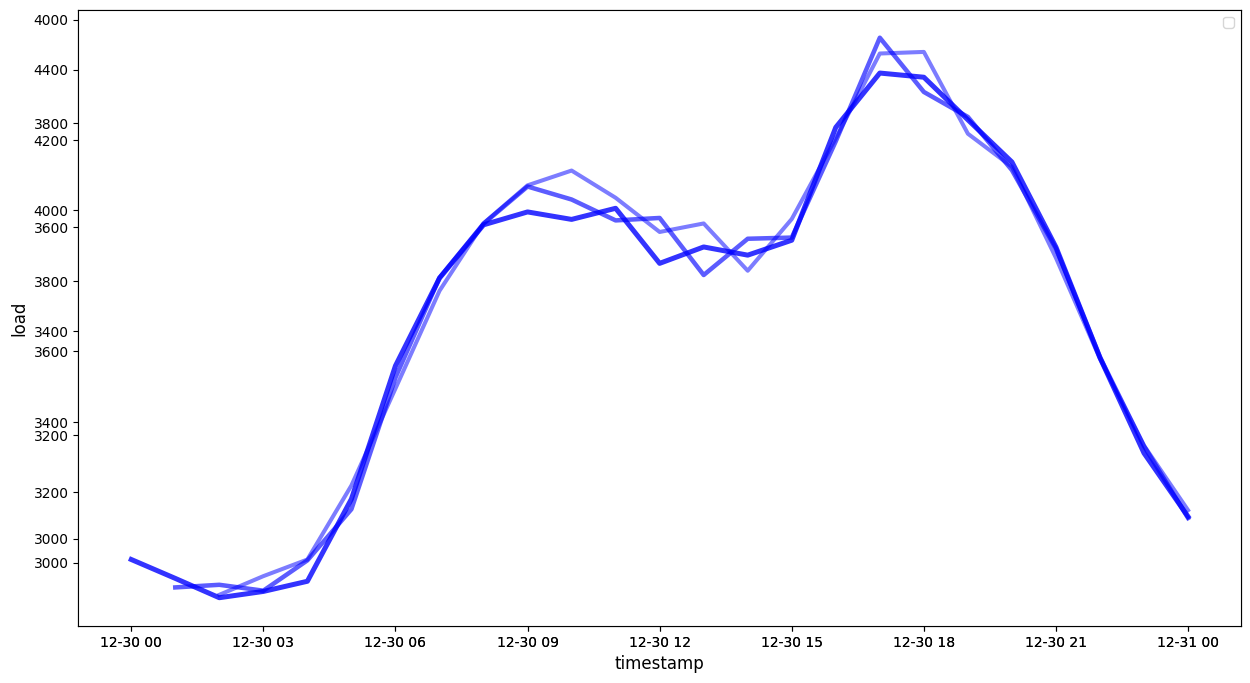

In [45]:
if(HORIZON == 1):
    ## Plotting single step forecast
    eval_df.plot(x='timestamp', y=['actual', 'prediction'], style=['r', 'b'], figsize=(15, 8))

else:
    ## Plotting multi step forecast
    plot_df = eval_df[(eval_df.h=='t+1')][['timestamp', 'actual']]
    for t in range(1, HORIZON+1):
        plot_df['t+'+str(t)] = eval_df[(eval_df.h=='t+'+str(t))]['prediction'].values

    fig = plt.figure(figsize=(15, 8))
    ax = plt.plot(plot_df['timestamp'], plot_df['actual'], color='red', linewidth=4.0)
    ax = fig.add_subplot(111)
    for t in range(1, HORIZON+1):
        x = plot_df['timestamp'][(t-1):]
        y = plot_df['t+'+str(t)][0:len(x)]
        ax.plot(x, y, color='blue', linewidth=4*math.pow(.9,t), alpha=math.pow(0.8,t))

    ax.legend(loc='best')

plt.xlabel('timestamp', fontsize=12)
plt.ylabel('load', fontsize=12)
plt.show()